# Next Character Prediction: Building Up from Scratch

**Goal:** Given a sequence of characters, predict the next character. We'll use this to *generate Indian names*.

We start with the **simplest possible model** and improve it one trick at a time:

| Version | What we add | Key idea |
|---------|------------|----------|
| V1 | Embedding + Linear | Simplest neural network for next char |
| V2 | Longer context | Look at more than 1 previous character |
| V3 | Hidden layer (MLP) | Learn non-linear patterns |
| V4 | Bigger embeddings | Richer character representations |
| V5 | Deeper network | More capacity |
| V6 | BatchNorm + Residual connections | Modern training tricks |

By the end, we'll generate realistic-sounding Indian names!

## Setup and Data

In [1]:
import torch
import torch.nn.functional as F
from torch import nn
import pandas as pd
import time
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cpu


### Load Indian Names Dataset

We use a dataset of ~6000 Indian names. Each name is a sequence of characters like `"nipun"`. We add a special `.` character to mark the start and end of names.

In [3]:
import os, requests

if not os.path.exists('names-long.csv'):
    url = "https://raw.githubusercontent.com/balasahebgulave/Dataset-Indian-Names/master/Indian_Names.csv"
    response = requests.get(url)
    with open('names-long.csv', 'w') as f:
        f.write(response.text)
    print("Downloaded!")

words = pd.read_csv('names-long.csv')["Name"]
words = words.str.lower().str.strip().str.replace(" ", "")
words = words[words.str.len().between(3, 9)]
words = words.sample(frac=1, random_state=42).reset_index(drop=True).tolist()
words = [w for w in words if w.isalpha()]

print(f"Total names: {len(words)}")
print(f"Examples: {words[:10]}")

Downloaded!
Total names: 6184
Examples: ['uday', 'shabila', 'grish', 'punni', 'devender', 'nisa', 'succha', 'gulnaaz', 'adityalok', 'bharti']


### Character Vocabulary

We map each character to an integer. The special `.` character (index 0) marks the start/end of a name.

In [4]:
chars = sorted(set(''.join(words)))
stoi = {ch: i+1 for i, ch in enumerate(chars)}
stoi['.'] = 0
itos = {i: ch for ch, i in stoi.items()}
vocab_size = len(stoi)

print(f"Vocabulary size: {vocab_size} characters")
print(f"Mapping: {itos}")

Vocabulary size: 27 characters
Mapping: {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


### Helper Functions

We'll reuse these throughout — for building datasets, training, generating names, and visualizing.

In [5]:
def build_dataset(words, block_size):
    """Build (context, target) pairs from words.
    
    For block_size=1 and word "cat":
        . -> c
        c -> a
        a -> t
        t -> .
    """
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X).to(device)
    Y = torch.tensor(Y).to(device)
    return X, Y


def train_model(model, X, Y, epochs=500, batch_size=2048, lr=1e-3, wd=1e-2, print_every=100):
    """Train with AdamW and return losses."""
    model.train()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    losses = []
    for epoch in range(epochs):
        total_loss, n = 0, 0
        for i in range(0, len(X), batch_size):
            logits = model(X[i:i+batch_size])
            loss = F.cross_entropy(logits, Y[i:i+batch_size])
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()
            n += 1
        avg = total_loss / n
        losses.append(avg)
        if epoch % print_every == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:4d} | Loss: {avg:.4f}")
    return losses


def generate_names(model, block_size, n=10, max_len=15):
    """Generate n names from the model."""
    model.eval()
    names = []
    with torch.no_grad():
        for _ in range(n):
            context = [0] * block_size
            name = ''
            for _ in range(max_len):
                x = torch.tensor([context]).to(device)
                logits = model(x)
                ix = torch.distributions.Categorical(logits=logits).sample().item()
                if ix == 0:
                    break
                name += itos[ix]
                context = context[1:] + [ix]
            names.append(name)
    model.train()
    return names


def show_names(names, title="Generated names"):
    """Pretty print generated names."""
    print(f"\n{title}")
    print("=" * 40)
    for i, name in enumerate(names, 1):
        print(f"  {i:2d}. {name}")


def count_params(model):
    """Count trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def plot_losses(*runs, labels=None):
    """Plot training loss curves for comparison."""
    fig, ax = plt.subplots(figsize=(8, 4))
    for i, losses in enumerate(runs):
        label = labels[i] if labels else f"V{i+1}"
        ax.plot(losses, label=label, alpha=0.8)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Training Loss Comparison")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_embeddings(emb, itos, title="Character Embeddings"):
    """Visualize embeddings in 2D (PCA if needed)."""
    weights = emb.weight.detach().cpu().numpy()
    
    if weights.shape[1] > 2:
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2)
        weights = pca.fit_transform(weights)
        title += f" (PCA: {pca.explained_variance_ratio_.sum():.0%} var)"
    
    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(len(itos)):
        x, y = weights[i, 0], weights[i, 1] if weights.shape[1] > 1 else 0
        color = 'red' if itos[i] == '.' else ('blue' if itos[i] in 'aeiou' else 'black')
        ax.scatter(x, y, c=color, s=60, zorder=5)
        ax.annotate(itos[i], (x, y), fontsize=12, fontweight='bold',
                    xytext=(5, 5), textcoords='offset points')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

---

## V1: The Simplest Model — Embedding + Linear (Bigram)

**Idea:** Look at just the **previous 1 character** (context=1) and predict the next one.

For the name `"nipun"`, we create these training examples:

```
. → n    (start of name → 'n')
n → i
i → p
p → u
u → n
n → .    ('n' → end of name)
```

**Architecture:**
- `Embedding(27, 2)` — each character gets a 2D vector
- `Linear(2, 27)` — predict scores for all 27 possible next characters

This is a **bigram model** — it only looks at the last character. Very limited, but let's see what happens!

In [6]:
# Build dataset with context=1 (bigram)
X1, Y1 = build_dataset(words, block_size=1)
print(f"Dataset: {X1.shape[0]} examples")
print(f"\nFirst 10 examples:")
for i in range(10):
    ctx = ''.join(itos[c.item()] for c in X1[i])
    print(f"  '{ctx}' → '{itos[Y1[i].item()]}'")


Dataset: 44325 examples

First 10 examples:


  '.' → 'u'
  'u' → 'd'
  'd' → 'a'
  'a' → 'y'
  'y' → '.'
  '.' → 's'
  's' → 'h'
  'h' → 'a'
  'a' → 'b'
  'b' → 'i'


In [7]:
class V1_BigramEmbedding(nn.Module):
    """Simplest model: Embedding(27,2) → Linear(2,27)"""
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, 2)
        self.linear = nn.Linear(2, vocab_size)
    
    def forward(self, x):
        x = self.emb(x)            # (B, 1, 2)
        x = x.view(x.shape[0], -1) # (B, 2)
        return self.linear(x)       # (B, 27)

model_v1 = V1_BigramEmbedding().to(device)
print(f"V1 parameters: {count_params(model_v1):,}")

show_names(generate_names(model_v1, block_size=1), "Before training (random)")

V1 parameters: 135

Before training (random)
   1. wojkfrlqzjnzmh
   2. avo
   3. ugcgixpxuesbbdp
   4. a
   5. 
   6. mvbeuiwkbxdkepq
   7. jcgdzuwblcvkdcv
   8. gkjeqqcenzrxnsk
   9. iseyebbmwburoam
  10. jzhcdnwfyfdrgom


In [8]:
losses_v1 = train_model(model_v1, X1, Y1, epochs=500, print_every=100)

Epoch    0 | Loss: 3.6227


Epoch  100 | Loss: 2.5362


Epoch  200 | Loss: 2.4916


Epoch  300 | Loss: 2.4869


Epoch  400 | Loss: 2.4863


Epoch  499 | Loss: 2.4862



V1: After training
   1. chinvitid
   2. san
   3. smalzitwumukema
   4. sam
   5. bashakam
   6. dusalamehidabwr
   7. enalinpi
   8. liesbin
   9. ar
  10. rnbijikhorin


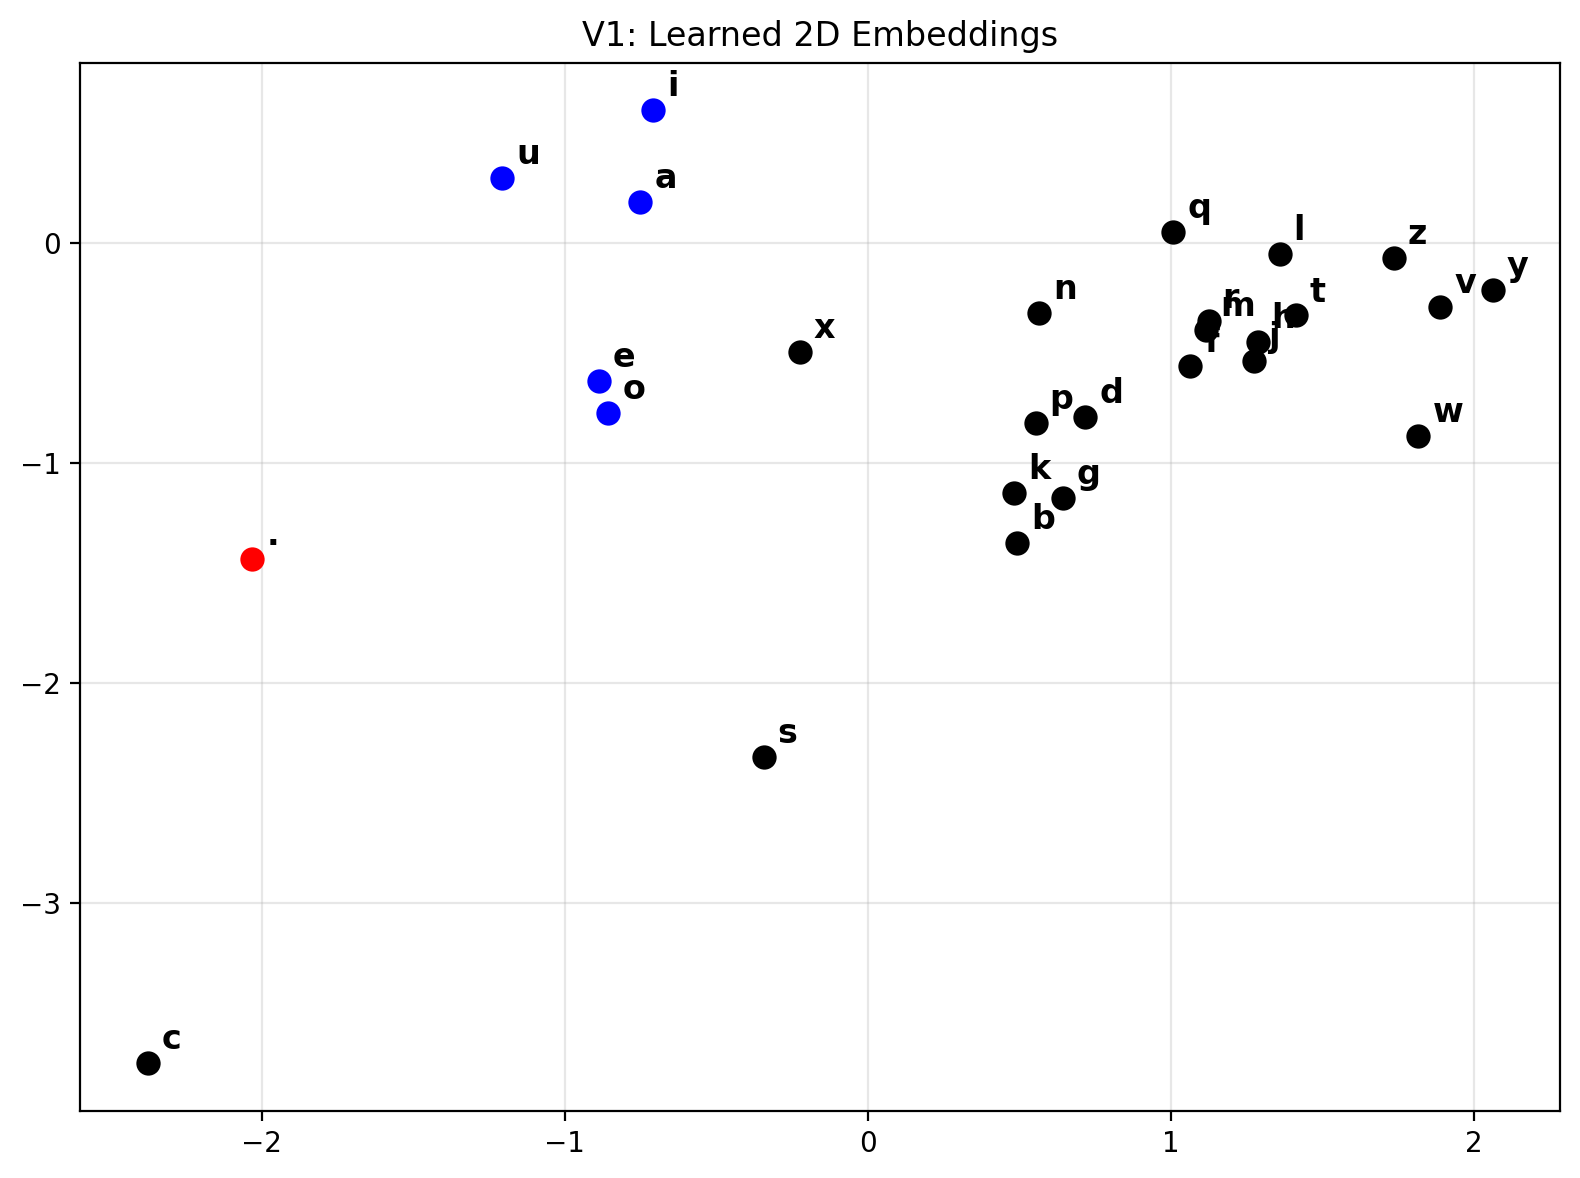

In [9]:
show_names(generate_names(model_v1, block_size=1), "V1: After training")
plot_embeddings(model_v1.emb, itos, "V1: Learned 2D Embeddings")

**Observations:**
- The names are mostly gibberish — because the model only sees 1 character at a time!
- If it sees `a`, it doesn't know if it's in "**a**mit" or "r**a**vi" — same prediction either way.
- Notice the embedding: vowels (blue) and consonants (black) start to separate.

**Limitation:** Context of 1 is way too short. Let's fix that.

---

## V2: Longer Context (block_size = 3)

**What changes:** Instead of looking at 1 previous character, we look at the **last 3**.

For `"nipun"`:
```
... → n
..n → i
.ni → p
nip → u
ipu → n
pun → .
```

Now the model can learn patterns like "after 'ni', 'p' is likely" or "after 'pu', 'n' is likely".

**Architecture:**
- `Embedding(27, 2)` — same 2D embeddings
- `Linear(3×2, 27)` — input is 3 embeddings concatenated = 6 numbers

In [10]:
X3, Y3 = build_dataset(words, block_size=3)
print(f"Dataset: {X3.shape[0]} examples, each with context of {X3.shape[1]} chars")
print(f"\nFirst 10 examples:")
for i in range(10):
    ctx = ''.join(itos[c.item()] for c in X3[i])
    print(f"  '{ctx}' → '{itos[Y3[i].item()]}'")


Dataset: 44325 examples, each with context of 3 chars

First 10 examples:
  '...' → 'u'
  '..u' → 'd'
  '.ud' → 'a'
  'uda' → 'y'
  'day' → '.'
  '...' → 's'
  '..s' → 'h'
  '.sh' → 'a'
  'sha' → 'b'
  'hab' → 'i'


In [11]:
class V2_LongerContext(nn.Module):
    """Same as V1 but with block_size=3: Embedding(27,2) → Linear(6,27)"""
    def __init__(self, block_size=3, emb_dim=2):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.linear = nn.Linear(block_size * emb_dim, vocab_size)
    
    def forward(self, x):
        x = self.emb(x)
        x = x.view(x.shape[0], -1)  # flatten: (B, 3, 2) → (B, 6)
        return self.linear(x)

model_v2 = V2_LongerContext(block_size=3).to(device)
print(f"V2 parameters: {count_params(model_v2):,}")
losses_v2 = train_model(model_v2, X3, Y3, epochs=500, print_every=100)

V2 parameters: 243
Epoch    0 | Loss: 3.3738


Epoch  100 | Loss: 2.4366


Epoch  200 | Loss: 2.3970


Epoch  300 | Loss: 2.3878


Epoch  400 | Loss: 2.3851


Epoch  499 | Loss: 2.3842



V2: Longer context (block=3)
   1. jilaez
   2. sesn
   3. amin
   4. ram
   5. jana
   6. nurtu
   7. rheoim
   8. ana
   9. cha
  10. 


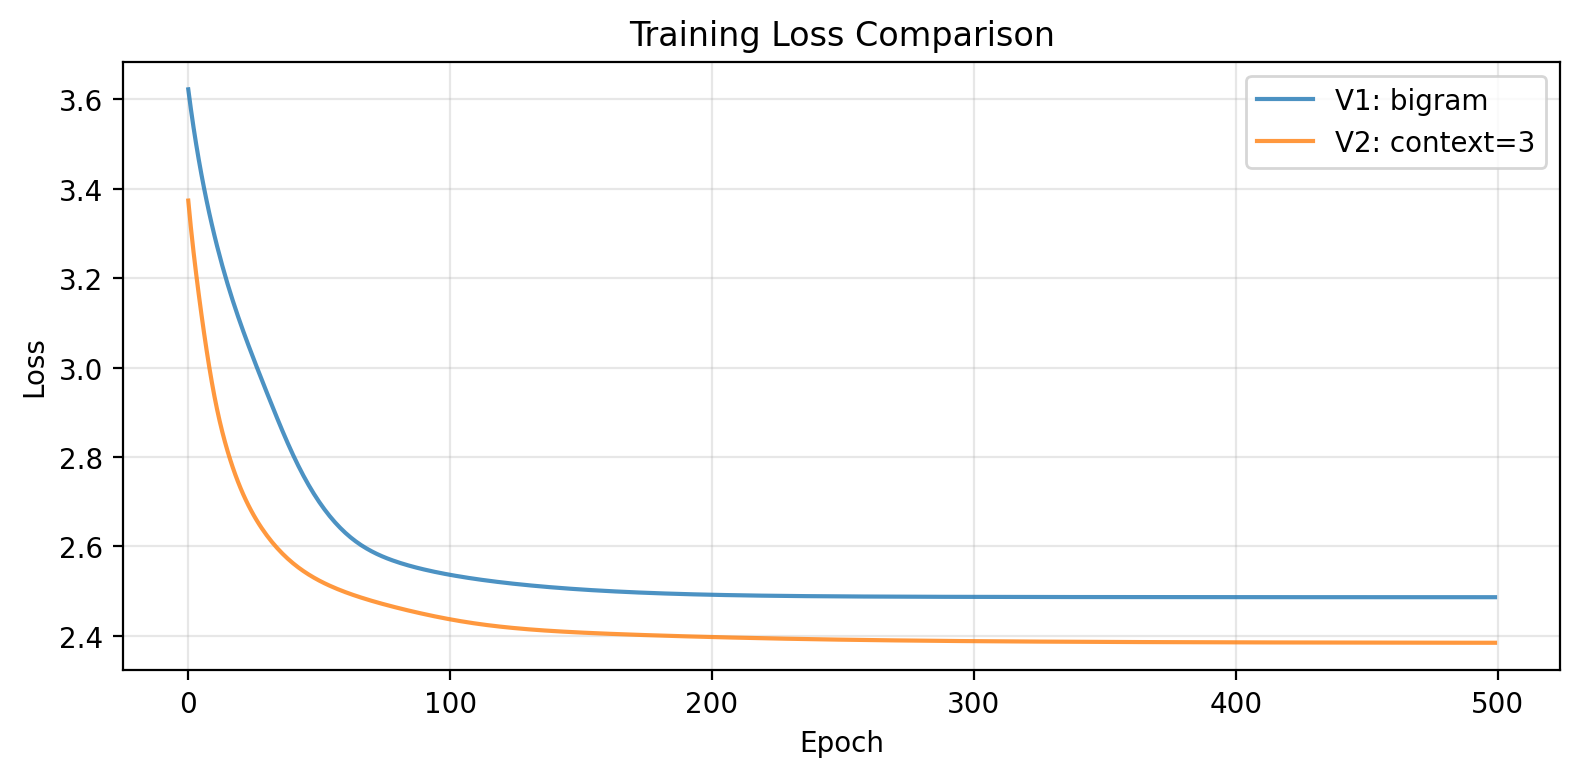

In [12]:
show_names(generate_names(model_v2, block_size=3), "V2: Longer context (block=3)")
plot_losses(losses_v1, losses_v2, labels=["V1: bigram", "V2: context=3"])

**Better!** The loss is lower and names start to look more name-like.

**But** the model is still just a linear function of the input embeddings — it can't learn complex patterns like "consonant clusters" or "vowel harmony". For that we need non-linearity.

---

## V3: Add a Hidden Layer (MLP)

**What changes:** We add a **hidden layer with an activation function** between the embeddings and the output.

```
Embedding → Linear(6, 64) → tanh → Linear(64, 27)
```

The hidden layer lets the model learn **non-linear combinations** of the input characters. For instance, it can learn that `"sh"` behaves differently from `"s"` followed by any other letter.

In [13]:
class V3_MLP(nn.Module):
    """Embedding → Hidden(64, tanh) → Output"""
    def __init__(self, block_size=3, emb_dim=2, hidden=64):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.lin1 = nn.Linear(block_size * emb_dim, hidden)
        self.lin2 = nn.Linear(hidden, vocab_size)
    
    def forward(self, x):
        x = self.emb(x)
        x = x.view(x.shape[0], -1)
        x = torch.tanh(self.lin1(x))  # non-linearity!
        return self.lin2(x)

model_v3 = V3_MLP(block_size=3).to(device)
print(f"V3 parameters: {count_params(model_v3):,}")
losses_v3 = train_model(model_v3, X3, Y3, epochs=500, print_every=100)

V3 parameters: 2,257
Epoch    0 | Loss: 3.2104


Epoch  100 | Loss: 2.2287


Epoch  200 | Loss: 2.1822


Epoch  300 | Loss: 2.1595


Epoch  400 | Loss: 2.1451


Epoch  499 | Loss: 2.1349



V3: MLP (hidden=64)
   1. tab
   2. rawyid
   3. ilsh
   4. jahender
   5. ram
   6. susrkhna
   7. jilal
   8. adhabta
   9. khander
  10. iqramb


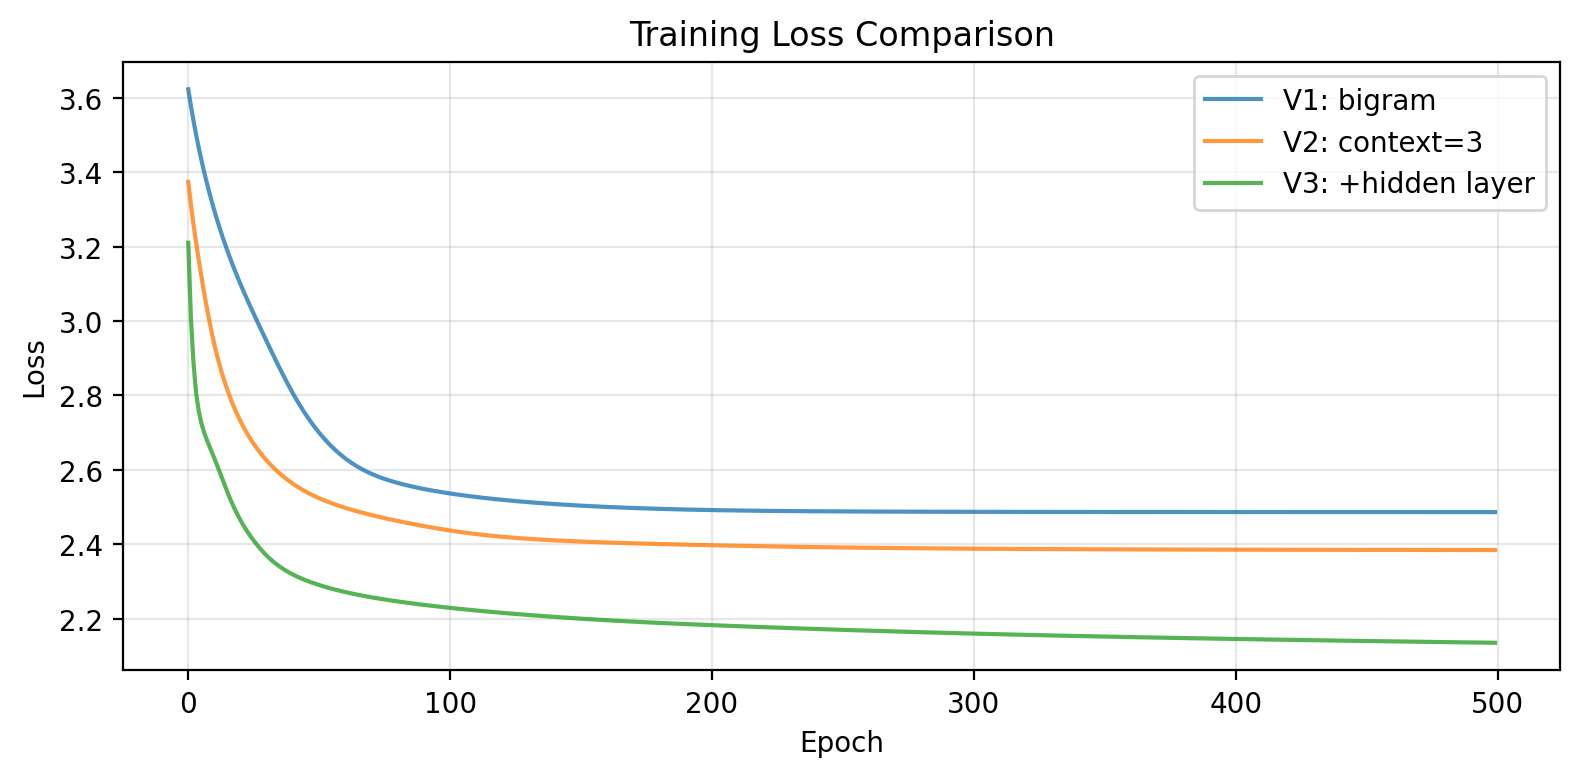

In [14]:
show_names(generate_names(model_v3, block_size=3), "V3: MLP (hidden=64)")
plot_losses(losses_v1, losses_v2, losses_v3, labels=["V1: bigram", "V2: context=3", "V3: +hidden layer"])

**Nice improvement!** The hidden layer captures non-linear character interactions.

But our embeddings are only 2D — each character is represented by just 2 numbers. Can we do better with richer representations?

---

## V4: Bigger Embeddings + Longer Context

**What changes:** Two improvements at once:
1. **Embedding dim: 2 → 8** — each character gets an 8-dimensional representation (more room to encode relationships)
2. **Context: 3 → 5** — look at 5 previous characters

**Architecture:**
```
Embedding(27, 8) → Linear(40, 128) → tanh → Linear(128, 27)
```

More parameters = more capacity to learn patterns.

In [15]:
X5, Y5 = build_dataset(words, block_size=5)
print(f"Dataset: {X5.shape[0]} examples, context of {X5.shape[1]} chars")

class V4_BiggerEmbeddings(nn.Module):
    """Bigger embeddings (8D) + longer context (5) + hidden layer (128)"""
    def __init__(self, block_size=5, emb_dim=8, hidden=128):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.lin1 = nn.Linear(block_size * emb_dim, hidden)
        self.lin2 = nn.Linear(hidden, vocab_size)
    
    def forward(self, x):
        x = self.emb(x)
        x = x.view(x.shape[0], -1)
        x = torch.tanh(self.lin1(x))
        return self.lin2(x)

model_v4 = V4_BiggerEmbeddings(block_size=5).to(device)
print(f"V4 parameters: {count_params(model_v4):,}")
losses_v4 = train_model(model_v4, X5, Y5, epochs=800, print_every=200)

Dataset: 44325 examples, context of 5 chars
V4 parameters: 8,947


Epoch    0 | Loss: 3.0946


Epoch  200 | Loss: 1.8638


Epoch  400 | Loss: 1.8017


Epoch  600 | Loss: 1.7734


Epoch  799 | Loss: 1.7564



V4: Bigger embeddings + context=5
   1. chamo
   2. vinka
   3. nasrum
   4. satwadhana
   5. ansadi
   6. lalalya
   7. rafal
   8. wadhyagit
   9. jisak
  10. zahab


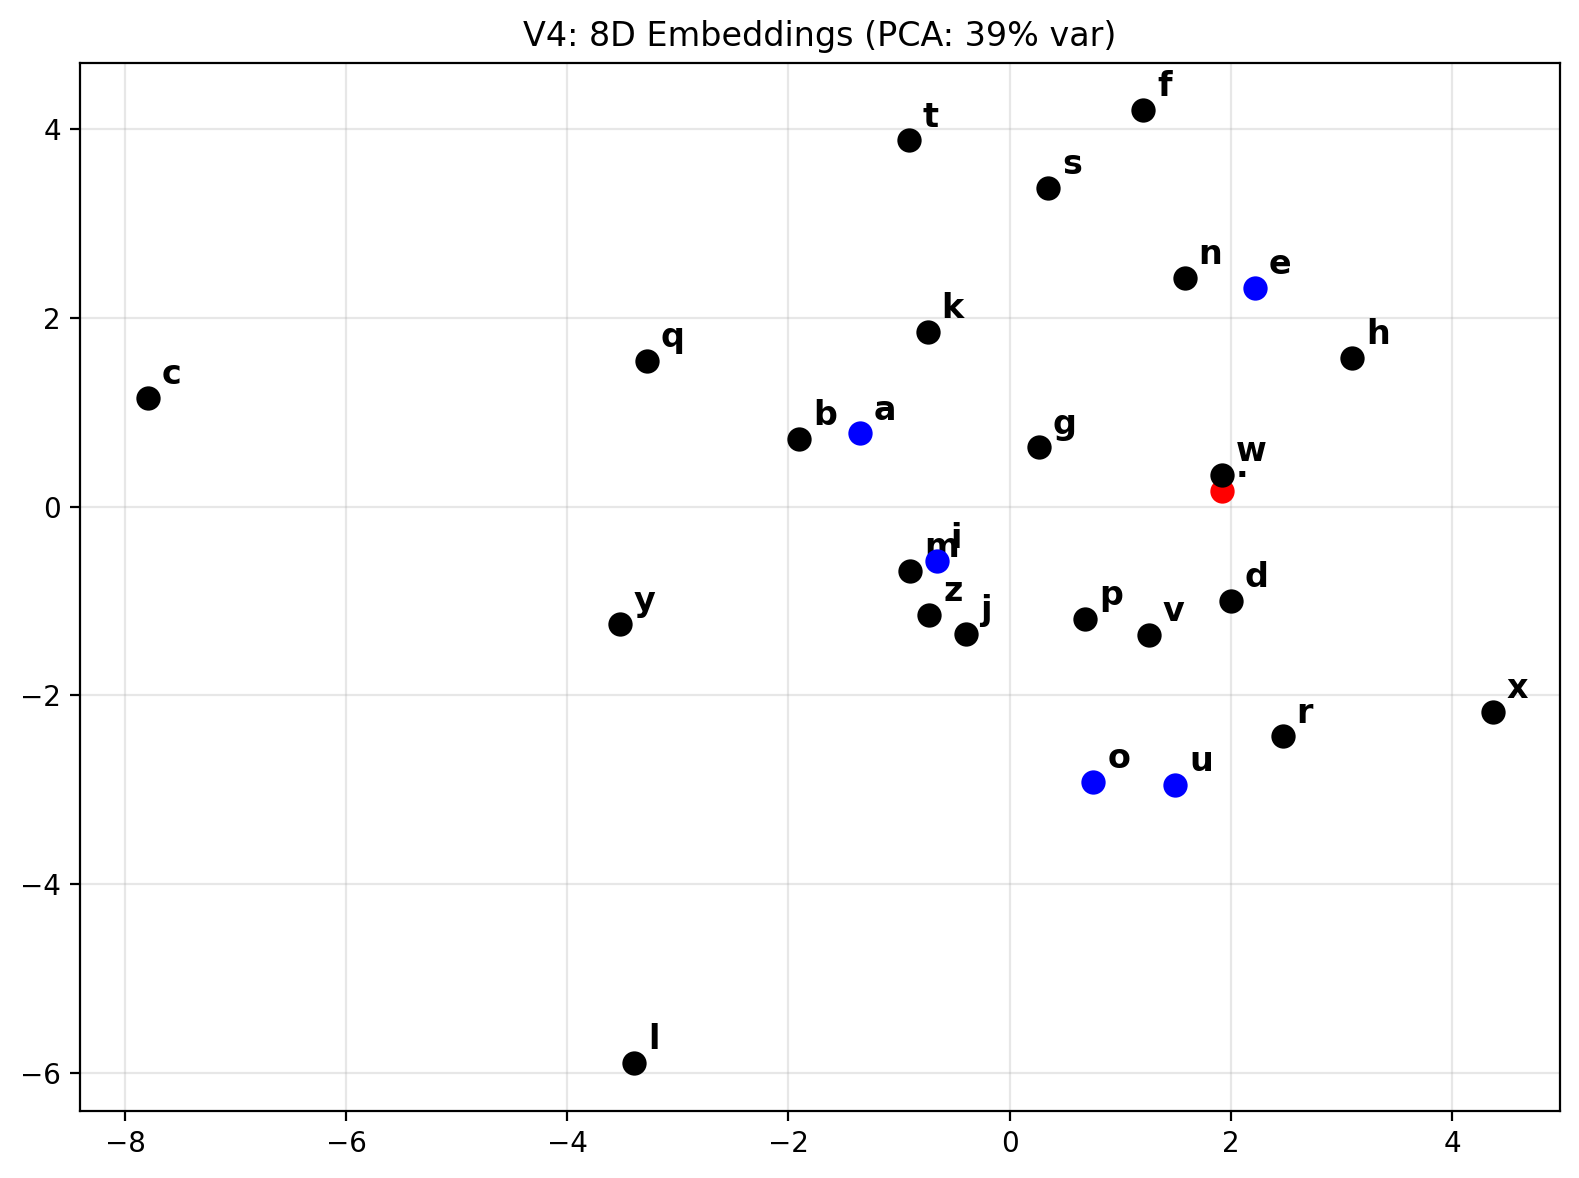

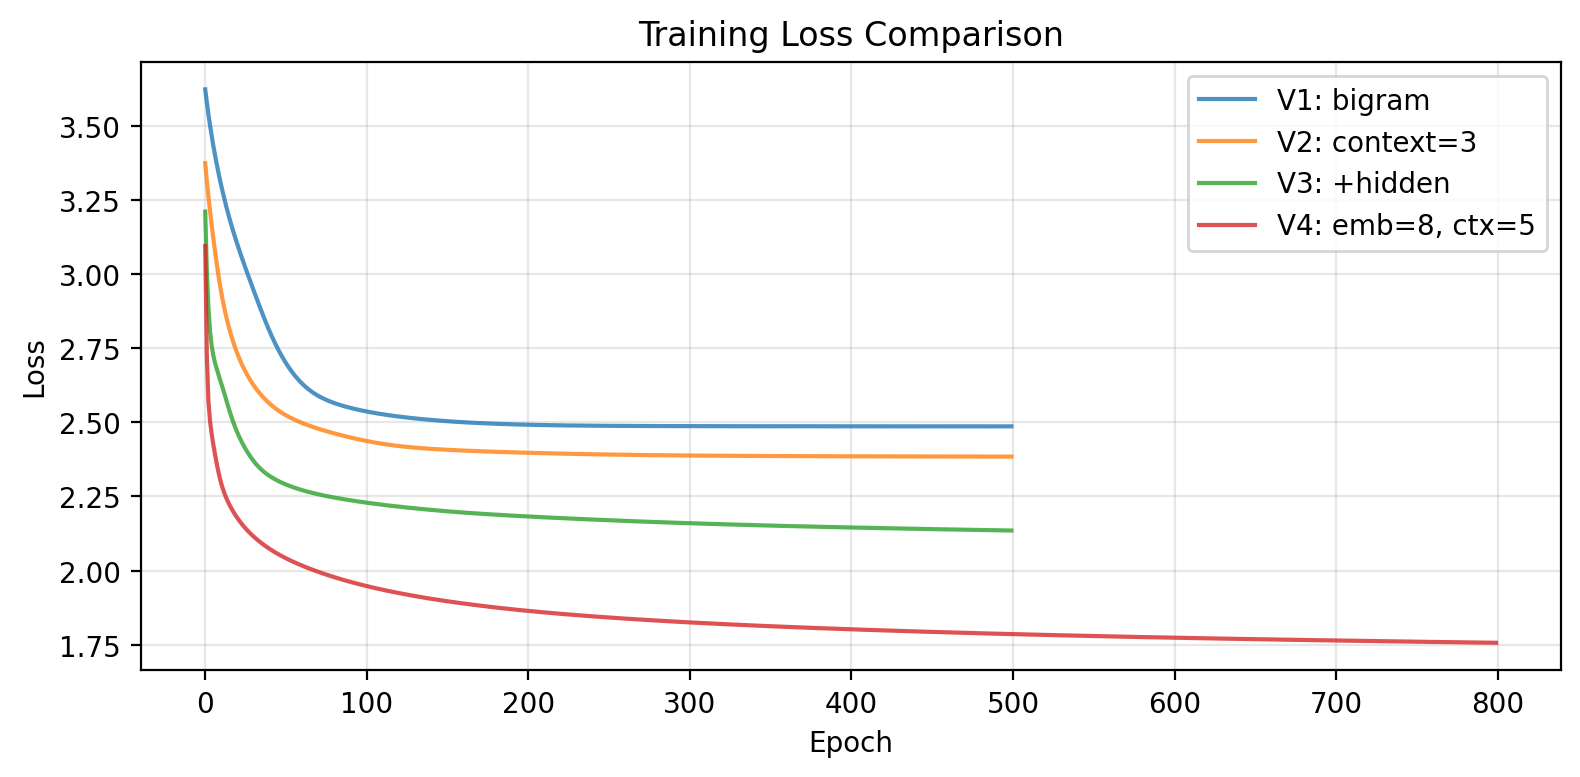

In [16]:
show_names(generate_names(model_v4, block_size=5), "V4: Bigger embeddings + context=5")
plot_embeddings(model_v4.emb, itos, "V4: 8D Embeddings")
plot_losses(losses_v1, losses_v2, losses_v3, losses_v4, 
            labels=["V1: bigram", "V2: context=3", "V3: +hidden", "V4: emb=8, ctx=5"])

**Names are getting better!** Notice how the embedding space (via PCA) shows more structure — vowels cluster together, similar-sounding consonants are nearby.

Can we squeeze out more performance with a deeper network?

---

## V5: Deeper Network (2 Hidden Layers)

**What changes:** We add a **second hidden layer**, giving the network more capacity to learn complex patterns.

```
Embedding(27, 8) → Linear(40, 128) → tanh → Linear(128, 128) → tanh → Linear(128, 27)
```

**Intuition:** The first hidden layer might learn basic character patterns (consonant-vowel pairs), while the second layer combines them into higher-level patterns (common syllables).

In [17]:
class V5_Deeper(nn.Module):
    """Two hidden layers: Embedding → H1(128) → H2(128) → Output"""
    def __init__(self, block_size=5, emb_dim=8, hidden=128):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.lin1 = nn.Linear(block_size * emb_dim, hidden)
        self.lin2 = nn.Linear(hidden, hidden)
        self.lin3 = nn.Linear(hidden, vocab_size)
    
    def forward(self, x):
        x = self.emb(x)
        x = x.view(x.shape[0], -1)
        x = torch.tanh(self.lin1(x))
        x = torch.tanh(self.lin2(x))
        return self.lin3(x)

model_v5 = V5_Deeper(block_size=5).to(device)
print(f"V5 parameters: {count_params(model_v5):,}")
losses_v5 = train_model(model_v5, X5, Y5, epochs=800, print_every=200)

V5 parameters: 25,459
Epoch    0 | Loss: 2.9272


Epoch  200 | Loss: 1.6739


Epoch  400 | Loss: 1.5072


Epoch  600 | Loss: 1.4293


Epoch  799 | Loss: 1.3867



V5: Deeper (2 hidden layers)
   1. veeren
   2. manphoishin
   3. mamraj
   4. chand
   5. khushnuhi
   6. mukaran
   7. tanisha
   8. saira
   9. paysha
  10. sajida


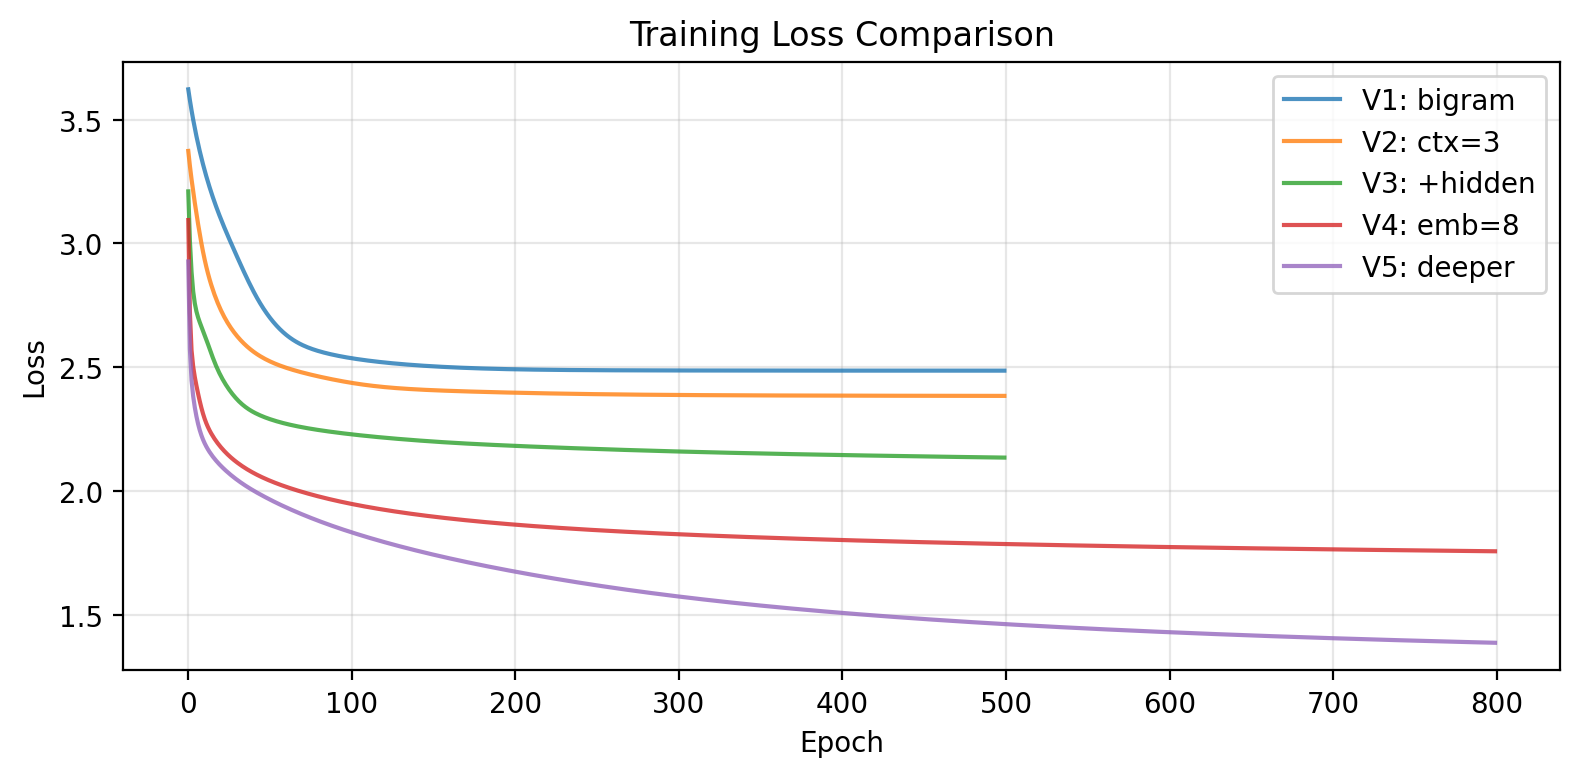

In [18]:
show_names(generate_names(model_v5, block_size=5), "V5: Deeper (2 hidden layers)")
plot_losses(losses_v1, losses_v2, losses_v3, losses_v4, losses_v5, 
            labels=["V1: bigram", "V2: ctx=3", "V3: +hidden", "V4: emb=8", "V5: deeper"])

**Deeper networks can be tricky to train.** You might notice the loss doesn't improve much (or is even worse!) than V4. This is a well-known problem:

- **Vanishing gradients:** In deep networks, gradients get smaller as they flow backward through many `tanh` layers
- **Training instability:** Random initialization can put the network in a bad region

Modern deep learning has solutions for this! Let's apply them.

---

## V6: Modern Tricks — BatchNorm + Residual + ReLU + Dropout

**What changes (all at once!):**

1. **ReLU instead of tanh** — doesn't saturate, gradients flow better
2. **BatchNorm** — normalizes activations, stabilizes training
3. **Residual connection** — adds a shortcut so gradients can flow directly through
4. **Dropout** — randomly zeros some neurons during training to prevent overfitting

```
Embedding → Linear(40, 128) → [Linear → BatchNorm → ReLU → Dropout → Linear] + skip → BatchNorm → ReLU → Output
```

This is essentially the architecture used in modern language models (at a much smaller scale)!

In [19]:
class V6_Modern(nn.Module):
    """Modern tricks: BatchNorm + Residual + ReLU + Dropout"""
    def __init__(self, block_size=5, emb_dim=8, hidden=128, dropout=0.1):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.fc_in = nn.Linear(block_size * emb_dim, hidden)
        
        # Residual block
        self.block = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
        )
        
        self.bn_out = nn.BatchNorm1d(hidden)
        self.fc_out = nn.Linear(hidden, vocab_size)

    def forward(self, x):
        x = self.emb(x)
        x = x.view(x.shape[0], -1)
        x = self.fc_in(x)
        x = x + self.block(x)    # ← residual connection!
        x = torch.relu(self.bn_out(x))
        return self.fc_out(x)

model_v6 = V6_Modern(block_size=5).to(device)
print(f"V6 parameters: {count_params(model_v6):,}")
losses_v6 = train_model(model_v6, X5, Y5, epochs=1000, print_every=200)

V6 parameters: 42,483


Epoch    0 | Loss: 2.8077


Epoch  200 | Loss: 1.6566


Epoch  400 | Loss: 1.5879


Epoch  600 | Loss: 1.5482


Epoch  800 | Loss: 1.5221


Epoch  999 | Loss: 1.5029



V6: Modern (BatchNorm + Residual)
   1. uzamu
   2. hardeep
   3. kamlesh
   4. rubiya
   5. ranaki
   6. chand
   7. subodh
   8. nazi
   9. prishoo
  10. kalish


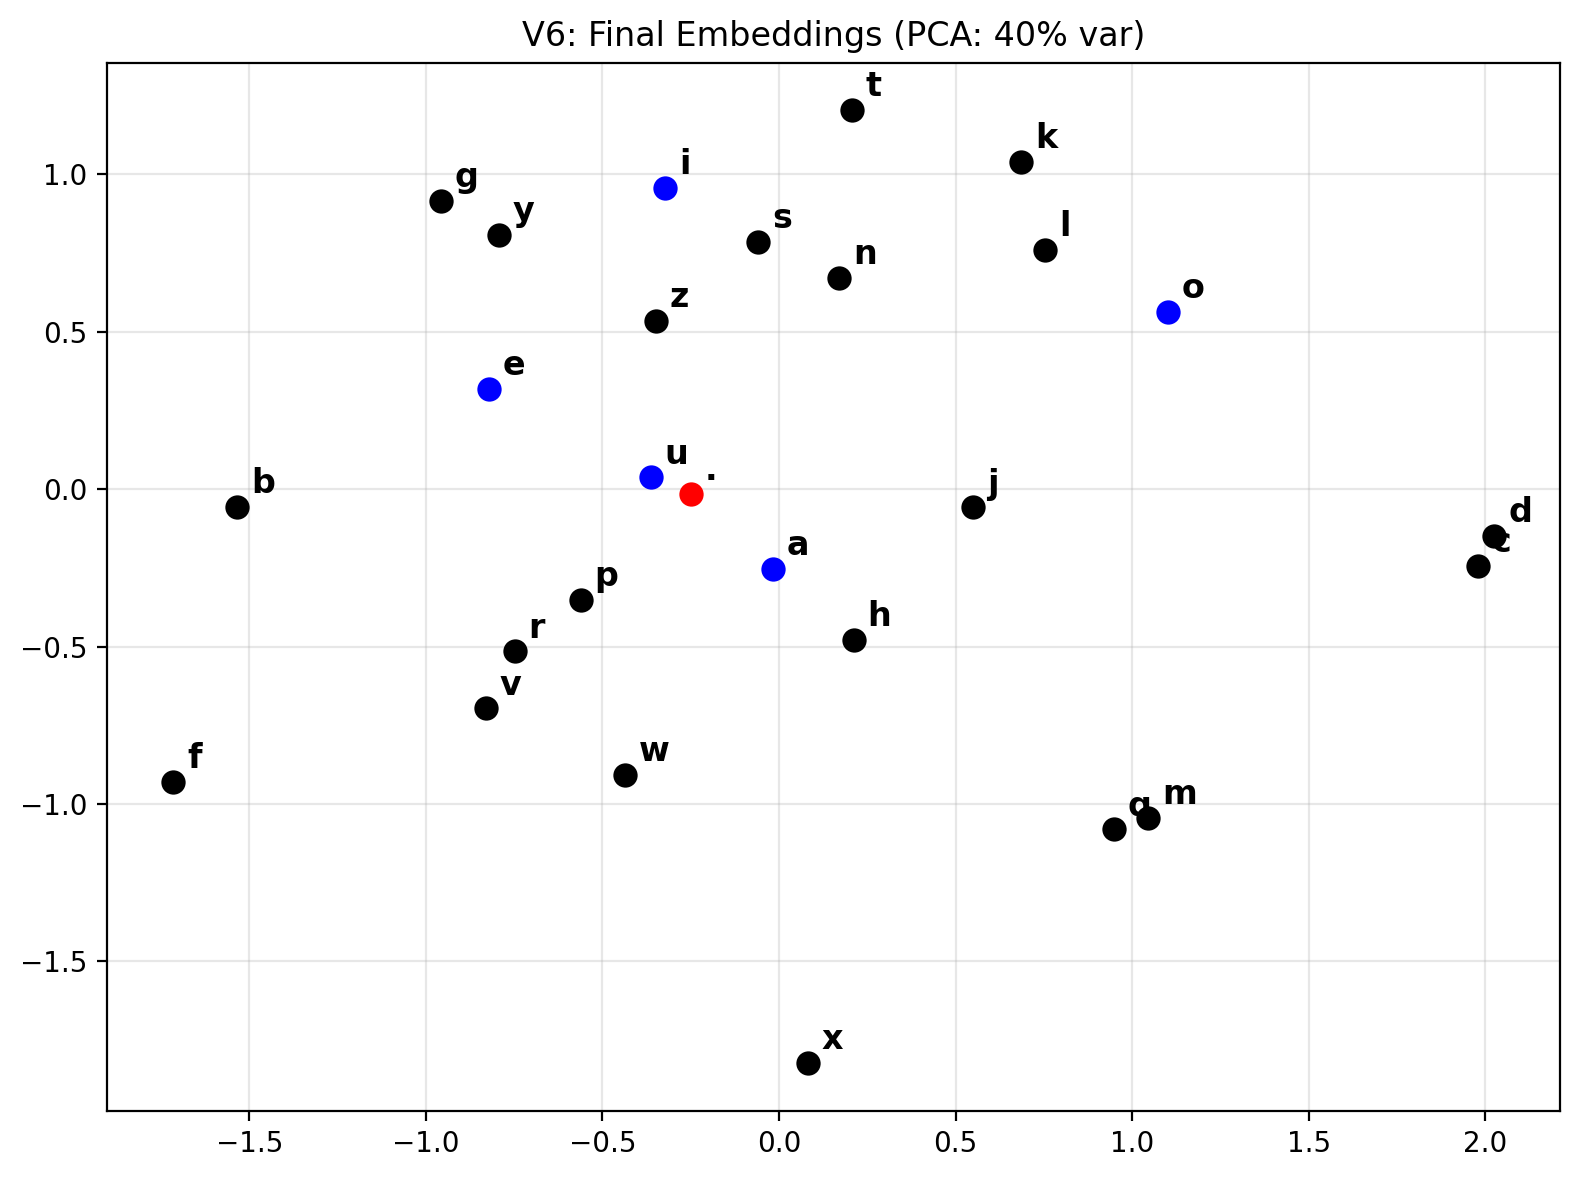

In [20]:
show_names(generate_names(model_v6, block_size=5), "V6: Modern (BatchNorm + Residual)")
plot_embeddings(model_v6.emb, itos, "V6: Final Embeddings")

---

## Final Comparison

Let's compare all models side by side.

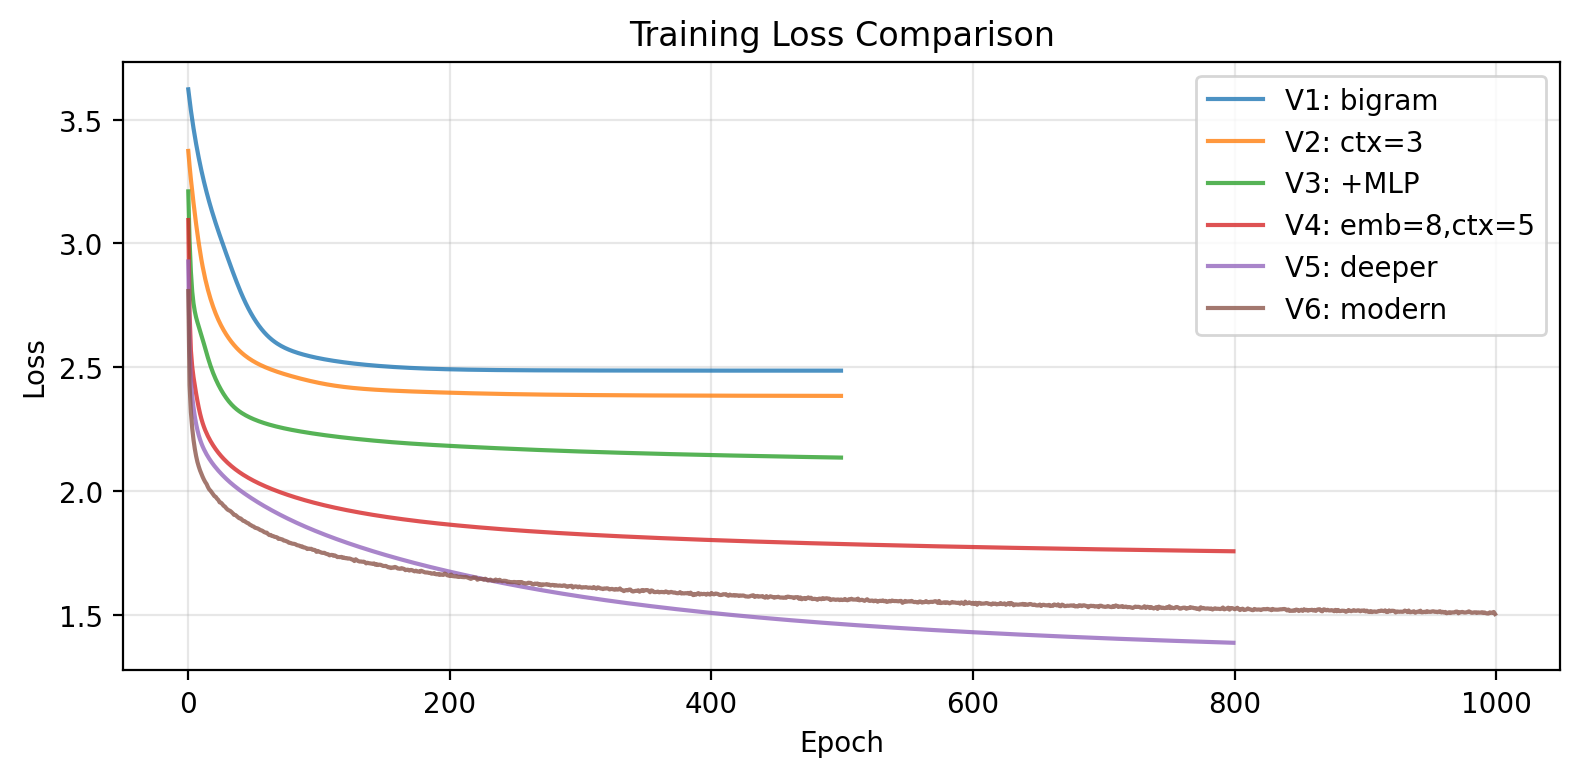


Model                       Params   Final Loss
V1: Bigram (emb=2)             135       2.4862
V2: Context=3 (emb=2)          243       2.3842
V3: +Hidden (64, tanh)       2,257       2.1349
V4: emb=8, ctx=5, h=128      8,947       1.7564
V5: +2nd hidden layer       25,459       1.3867
V6: +BN+Residual+ReLU       42,483       1.5029


In [21]:
# Loss comparison
plot_losses(losses_v1, losses_v2, losses_v3, losses_v4, losses_v5, losses_v6,
            labels=["V1: bigram", "V2: ctx=3", "V3: +MLP", "V4: emb=8,ctx=5", "V5: deeper", "V6: modern"])

# Summary table
print("\n" + "=" * 65)
print(f"{'Model':<25} {'Params':>8} {'Final Loss':>12}")
print("=" * 65)
models_info = [
    ("V1: Bigram (emb=2)", model_v1, losses_v1),
    ("V2: Context=3 (emb=2)", model_v2, losses_v2),
    ("V3: +Hidden (64, tanh)", model_v3, losses_v3),
    ("V4: emb=8, ctx=5, h=128", model_v4, losses_v4),
    ("V5: +2nd hidden layer", model_v5, losses_v5),
    ("V6: +BN+Residual+ReLU", model_v6, losses_v6),
]
for name, m, l in models_info:
    print(f"{name:<25} {count_params(m):>8,} {l[-1]:>12.4f}")
print("=" * 65)

In [22]:
# Side-by-side name generation from all models
print("\nGenerated names from each version:")
print("=" * 65)
all_models = [
    ("V1: Bigram",  model_v1, 1),
    ("V2: ctx=3",   model_v2, 3),
    ("V3: +MLP",    model_v3, 3),
    ("V4: emb=8",   model_v4, 5),
    ("V5: deeper",  model_v5, 5),
    ("V6: modern",  model_v6, 5),
]
for name, m, bs in all_models:
    names = generate_names(m, bs, n=5)
    print(f"  {name:<15} → {', '.join(names)}")


Generated names from each version:
  V1: Bigram      → i, kpadibivaorilar, sa, kinruswinur, shura
  V2: ctx=3       → lini, shje, suru, omtemyarjojhran, lanman
  V3: +MLP        → seemul, bir, sha, dam, bma
  V4: emb=8       → bakheshwin, tosali, dharmendra, ranum, sanu
  V5: deeper      → bhagy, devakshilajat, shike, pardha, rosasthmin
  V6: modern      → revmaji, joycee, sehzaz, avi, maahbir


---

## What We Learned

Each improvement addressed a specific limitation:

| Step | What we added | Why it helped |
|------|--------------|---------------|
| V1 → V2 | Longer context | Model can see letter combinations, not just single chars |
| V2 → V3 | Hidden layer + tanh | Non-linear patterns (e.g., "sh" behaves as a unit) |
| V3 → V4 | Bigger embeddings + context | Richer character representations, more history |
| V4 → V5 | Deeper network | More capacity — but harder to train! |
| V5 → V6 | BatchNorm + Residual + ReLU + Dropout | Fixes training issues in deep networks |

**This is exactly the story of modern AI:**
- GPT/Claude use the same ideas at a much larger scale
- Instead of 27 characters → 100,000+ tokens (subwords)
- Instead of 5 chars context → 100,000+ tokens context
- Instead of 128 hidden units → billions of parameters
- Same core loop: **embed → transform → predict next token**

## Tuning Knobs to Explore

Try changing these and see what happens:
1. **Embedding dimension** — 2 vs 8 vs 16
2. **Hidden layer size** — 64 vs 128 vs 256
3. **Context length** — 3 vs 5 vs 8
4. **Number of layers** — 1 vs 2 vs 3
5. **Activation function** — tanh vs ReLU vs GELU
6. **Learning rate** — 1e-2 vs 1e-3 vs 1e-4